In [27]:
import pandas as pd
def read(filepath,type):
    """
    Read data from a file.

    Args:
        filepath (str): The path to the file.
        type (str): The type of the file ('csv' or 'json').

    Returns:
        pandas.DataFrame: The loaded data.
    """
    if type == 'csv':
        data = pd.read_csv(filepath)
    elif type == 'json':
        data = pd.read_json(filepath)
    else:
        raise ValueError("Unsupported file type")
    data = pd.DataFrame(data)
    return data



In [28]:
sample_data = read('C:\\Users\\ferva\\OneDrive\\UX_Project\\modules\\sample_ux_data.csv', 'csv')
print(sample_data.head())
sample_data.info()

  userid sessionid            timestamp event_type     page
0     U1        S1  2026-04-01 10:00:00  page_view     home
1     U1        S1  2026-04-01 10:01:10      click  product
2     U1        S1  2026-04-01 10:03:00     scroll  product
3     U2        S2  2026-04-01 11:00:00  page_view  landing
4     U2        S2  2026-04-01 11:02:30      click   signup
<class 'pandas.DataFrame'>
RangeIndex: 8 entries, 0 to 7
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   userid      8 non-null      str  
 1   sessionid   8 non-null      str  
 2   timestamp   8 non-null      str  
 3   event_type  8 non-null      str  
 4   page        8 non-null      str  
dtypes: str(5)
memory usage: 452.0 bytes


In [29]:
def standardize_time(data):
    """
     Standardize the timestamp column to datetime format.
    """
    data['timestamp'] = pd.to_datetime(data['timestamp'])
    return data

In [30]:
sample_data = standardize_time(sample_data)
print(sample_data.info())

<class 'pandas.DataFrame'>
RangeIndex: 8 entries, 0 to 7
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   userid      8 non-null      str           
 1   sessionid   8 non-null      str           
 2   timestamp   8 non-null      datetime64[us]
 3   event_type  8 non-null      str           
 4   page        8 non-null      str           
dtypes: datetime64[us](1), str(4)
memory usage: 452.0 bytes
None


In [31]:
def rename_columns(data, original_columns=['user_id','session_id','timestamp','event_type']):
    data = data.rename(columns= {original_columns[0]:'user_id', original_columns[1]:'session_id', original_columns[2]:'timestamp', original_columns[3]:'event_type'})
    return data

In [32]:
mycolumns = sample_data.columns.tolist()
renamed_data = rename_columns(sample_data, mycolumns)
print(renamed_data.head())

  user_id session_id           timestamp event_type     page
0      U1         S1 2026-04-01 10:00:00  page_view     home
1      U1         S1 2026-04-01 10:01:10      click  product
2      U1         S1 2026-04-01 10:03:00     scroll  product
3      U2         S2 2026-04-01 11:00:00  page_view  landing
4      U2         S2 2026-04-01 11:02:30      click   signup


In [33]:
def session_duration(data):
    """
    Calculate session duration for each session.
    """
    session_times = data.groupby('session_id')['timestamp'].agg(['min', 'max'])
    session_times['session_duration'] = (session_times['max'] - session_times['min']).dt.total_seconds()
    data = data.merge(session_times['session_duration'], on='session_id', how='left')
    return data

In [34]:
final_data = session_duration(renamed_data)
print(final_data.head())

  user_id session_id           timestamp event_type     page  session_duration
0      U1         S1 2026-04-01 10:00:00  page_view     home             180.0
1      U1         S1 2026-04-01 10:01:10      click  product             180.0
2      U1         S1 2026-04-01 10:03:00     scroll  product             180.0
3      U2         S2 2026-04-01 11:00:00  page_view  landing             150.0
4      U2         S2 2026-04-01 11:02:30      click   signup             150.0


In [35]:
def events_per_session(data):
    """
    Calculate the number of events per session.

    Returns:
        data with new column events_per_session
    """
    events_count = data.groupby('session_id').count()
    events_count['events_per_session'] = events_count['event_type']
    data = data.merge(events_count['events_per_session'], on='session_id')
    return data
data3 = events_per_session(final_data)
data3.head()


,user_id,session_id,timestamp,event_type,page,session_duration,events_per_session
0,U1,S1,2026-04-01 10:00:00,page_view,home,180.0,3
1,U1,S1,2026-04-01 10:01:10,click,product,180.0,3
2,U1,S1,2026-04-01 10:03:00,scroll,product,180.0,3
3,U2,S2,2026-04-01 11:00:00,page_view,landing,150.0,2
4,U2,S2,2026-04-01 11:02:30,click,signup,150.0,2


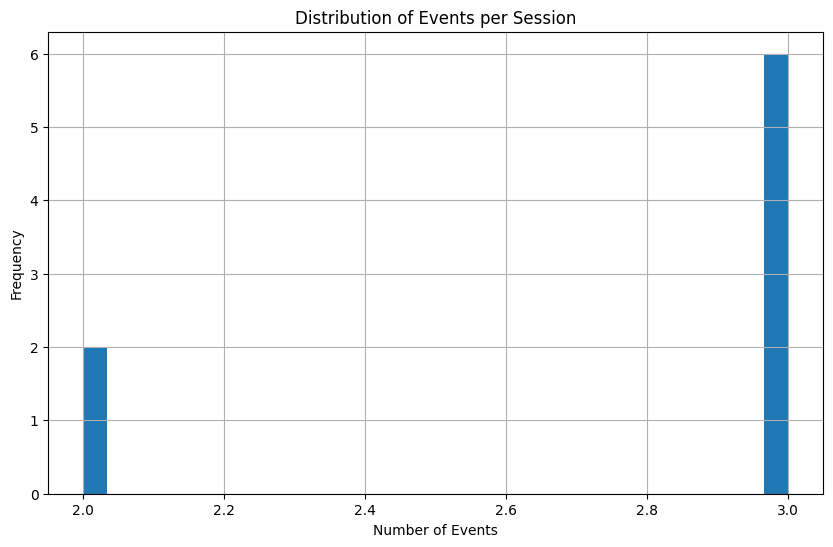

In [37]:
import matplotlib.pyplot as plt
def plot_events_per_session(data, figsize=(10, 6)):
    """
    Plot the distribution of events per session.
    """
    plt.figure(figsize=figsize)
    data['events_per_session'].hist(bins=30)
    plt.title('Distribution of Events per Session')
    plt.xlabel('Number of Events')
    plt.ylabel('Frequency')
    plt.show()

plot_events_per_session(data3)

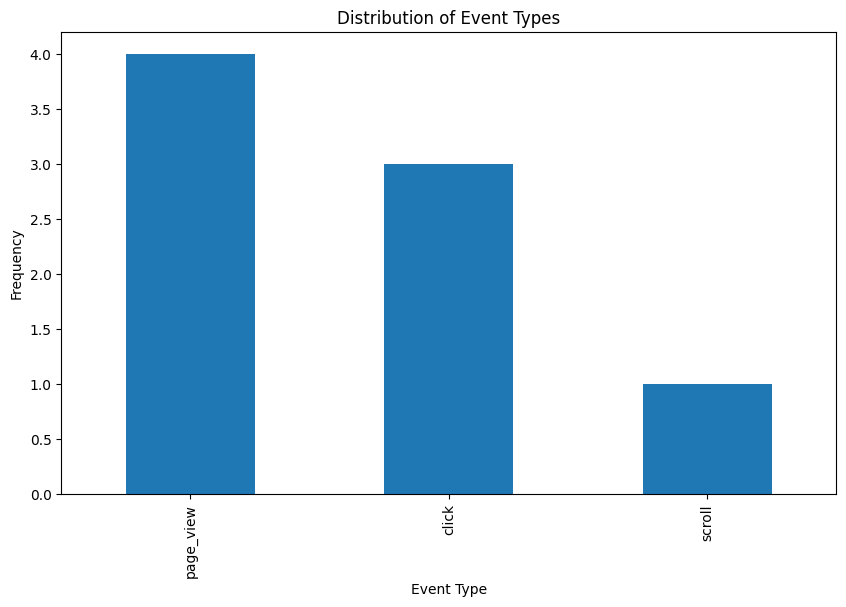

In [ ]:
def plot_event_types(data,figsize=(10, 6)):
    """
    Plot the distribution of event types.
    """
    plt.figure(figsize=figsize)
    data['event_type'].value_counts().plot(kind='bar')
    plt.title('Distribution of Event Types')
    plt.xlabel('Event Type')
    plt.ylabel('Frequency')
    plt.show()
plot_event_types(final_data)